# CodeAlpha Data Analytics Internship
# TASK 2: Exploratory Data Analysis (EDA)
# Dataset: Titanic (via seaborn built-in)
# Author: Mahnoor

## **IMPORT LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **LOAD DATASET**

In [ ]:
df = sns.load_dataset('titanic')

print("=" * 55)
print("        TITANIC DATASET — EXPLORATORY DATA ANALYSIS")
print("=" * 55)

        TITANIC DATASET — EXPLORATORY DATA ANALYSIS


## **DATASET OVERVIEW**

In [ ]:
print("\n[1] Shape of Dataset:", df.shape)
print("\n[2] Column Names:\n", df.columns.tolist())
print("\n[3] Data Types:\n", df.dtypes)
print("\n[4] First 5 Rows:\n", df.head())



[1] Shape of Dataset: (891, 15)

[2] Column Names:
 ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

[3] Data Types:
 survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

[4] First 5 Rows:
    survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4        

## **MISSING VALUE ANALYSIS**

In [ ]:
print("\n[5] Missing Values per Column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])


[5] Missing Values per Column:
             Missing Count  Missing %
age                    177  19.865320
embarked                 2   0.224467
deck                   688  77.216611
embark_town              2   0.224467


## **DESCRIPTIVE STATISTICS**

In [ ]:
print("\n[6] Descriptive Statistics (Numeric):")
print(df.describe())

print("\n[7] Descriptive Statistics (Categorical):")
print(df.describe(include=['object', 'category']))


[6] Descriptive Statistics (Numeric):
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200

[7] Descriptive Statistics (Categorical):
         sex embarked  class  who deck  embark_town alive
count    891      889    891  891  203          889   891
unique     2        3      3    3    7            3     2
top     male        S  Third  man    C  So

## **HYPOTHESIS:** Do women survive more than men?

In [ ]:
print("\n[9] Survival Rate by Passenger Class:")
print(df.groupby('pclass')['survived'].mean().round(3))


[9] Survival Rate by Passenger Class:
pclass
1    0.630
2    0.473
3    0.242
Name: survived, dtype: float64


## **HYPOTHESIS:** Do higher class passengers survive more?

In [ ]:
print("\n[9] Survival Rate by Passenger Class:")
print(df.groupby('pclass')['survived'].mean().round(3))


[9] Survival Rate by Passenger Class:
pclass
1    0.630
2    0.473
3    0.242
Name: survived, dtype: float64


## **OUTLIER DETECTION — Age & Fare using IQR**

In [ ]:
def detect_outliers(col):
    clean_col = df[col].dropna()
    Q1 = clean_col.quantile(0.25)
    Q3 = clean_col.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = clean_col[(clean_col < lower) | (clean_col > upper)]
    return len(outliers)

print("\n[10] Outlier Count:")
print(f"  Age  → {detect_outliers('age')} outliers")
print(f"  Fare → {detect_outliers('fare')} outliers")


[10] Outlier Count:
  Age  → 11 outliers
  Fare → 116 outliers


## **CORRELATION MATRIX (numeric only)**

In [ ]:
print("\n[11] Correlation Matrix (numeric columns):")
numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
numeric_df = df[numeric_cols]
corr_matrix = numeric_df.corr().round(2)
print(corr_matrix)


[11] Correlation Matrix (numeric columns):
          survived  pclass   age  sibsp  parch  fare
survived      1.00   -0.34 -0.08  -0.04   0.08  0.26
pclass       -0.34    1.00 -0.37   0.08   0.02 -0.55
age          -0.08   -0.37  1.00  -0.31  -0.19  0.10
sibsp        -0.04    0.08 -0.31   1.00   0.41  0.16
parch         0.08    0.02 -0.19   0.41   1.00  0.22
fare          0.26   -0.55  0.10   0.16   0.22  1.00


## **VISUALIZATIONS**

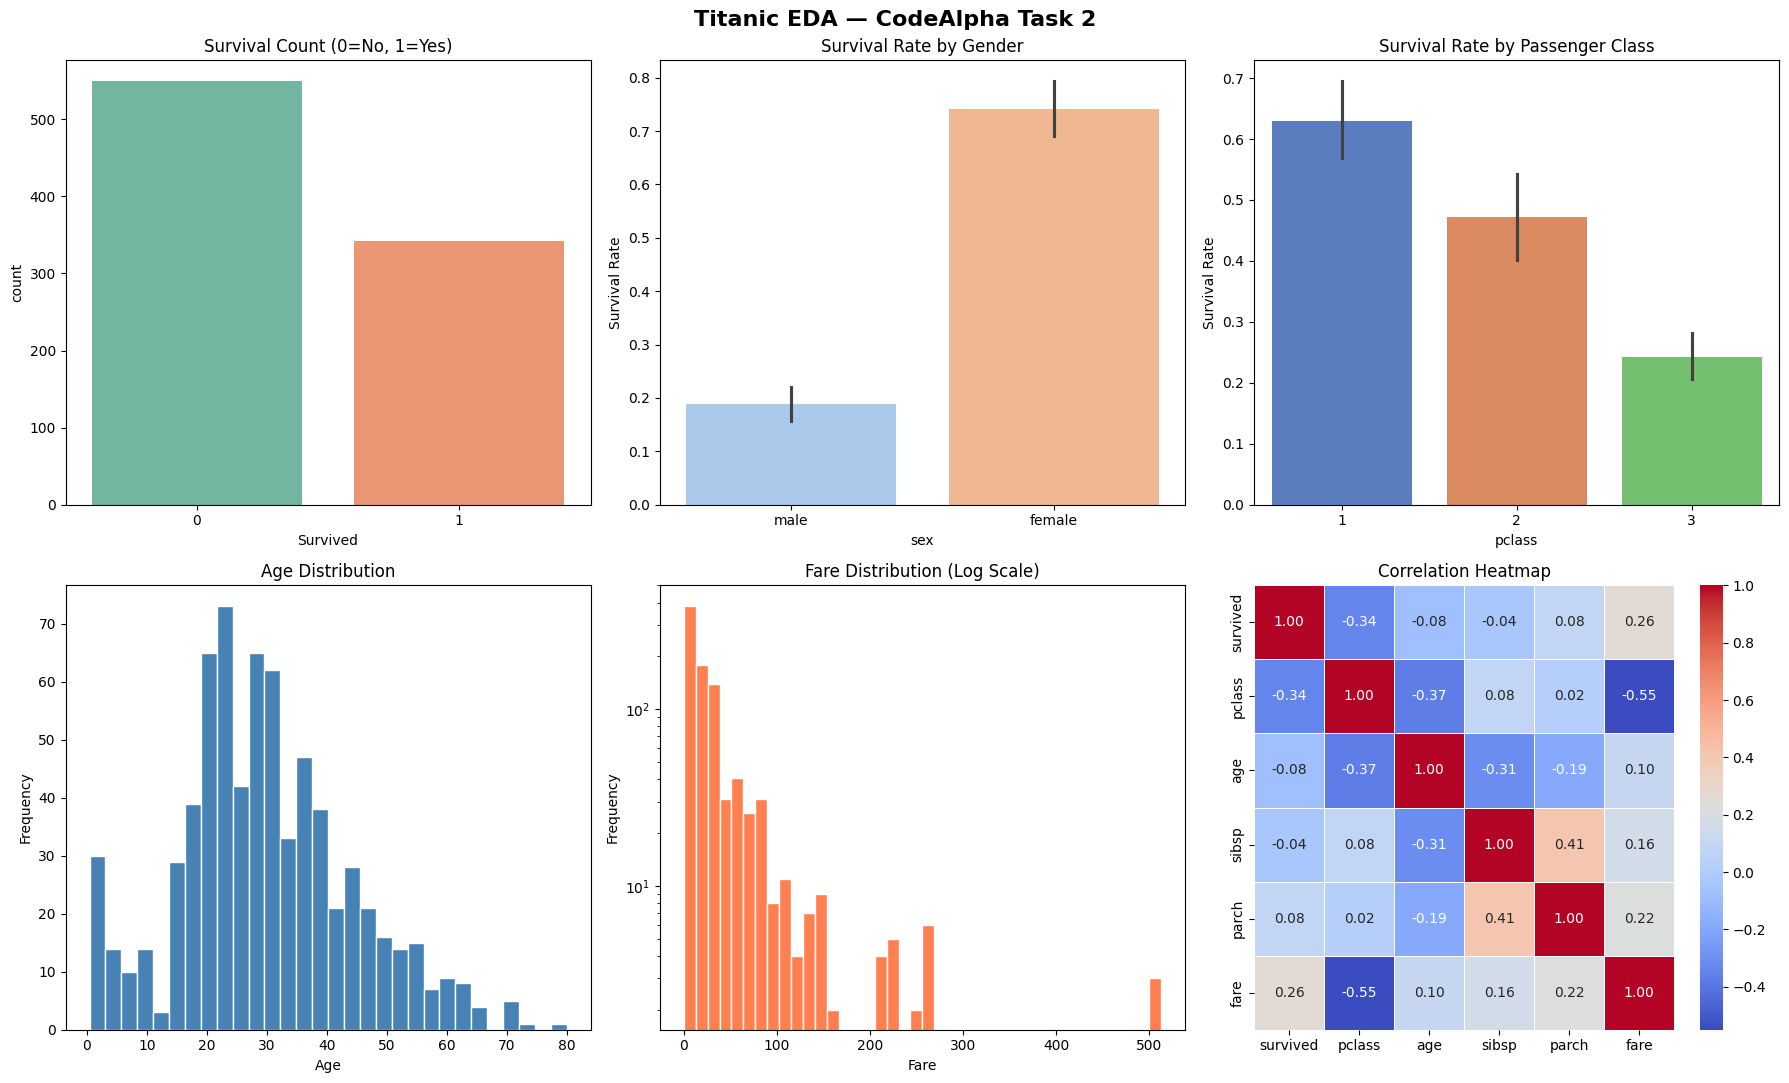


[✓] EDA complete. Plot saved as 'task2_eda_output.png'


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Titanic EDA — CodeAlpha Task 2', fontsize=16, fontweight='bold')

# Plot 1: Survival Count (Added 'hue' to fix FutureWarning)
sns.countplot(x='survived', hue='survived', data=df, palette='Set2', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Survival Count (0=No, 1=Yes)')
axes[0, 0].set_xlabel('Survived')

# Plot 2: Survival by Gender
sns.barplot(x='sex', y='survived', hue='sex', data=df, palette='pastel', legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Survival Rate by Gender')
axes[0, 1].set_ylabel('Survival Rate')

# Plot 3: Survival by Passenger Class
sns.barplot(x='pclass', y='survived', hue='pclass', data=df, palette='muted', legend=False, ax=axes[0, 2])
axes[0, 2].set_title('Survival Rate by Passenger Class')
axes[0, 2].set_ylabel('Survival Rate')

# Plot 4: Age Distribution
df['age'].dropna().plot(kind='hist', bins=30, color='steelblue',
                        edgecolor='white', ax=axes[1, 0])
axes[1, 0].set_title('Age Distribution')
axes[1, 0].set_xlabel('Age')

# Plot 5: Fare Distribution (Log scale apply kar diya hai real skewness handle karne ke liye)
df['fare'].dropna().plot(kind='hist', bins=40, color='coral',
                        edgecolor='white', ax=axes[1, 1])
axes[1, 1].set_yscale('log') # Log scale enabling
axes[1, 1].set_title('Fare Distribution (Log Scale)')
axes[1, 1].set_xlabel('Fare')

# Plot 6: Correlation Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=axes[1, 2])
axes[1, 2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('task2_eda_output.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[✓] EDA complete. Plot saved as 'task2_eda_output.png'")